In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Fish.csv')

In [4]:
df.head()   

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


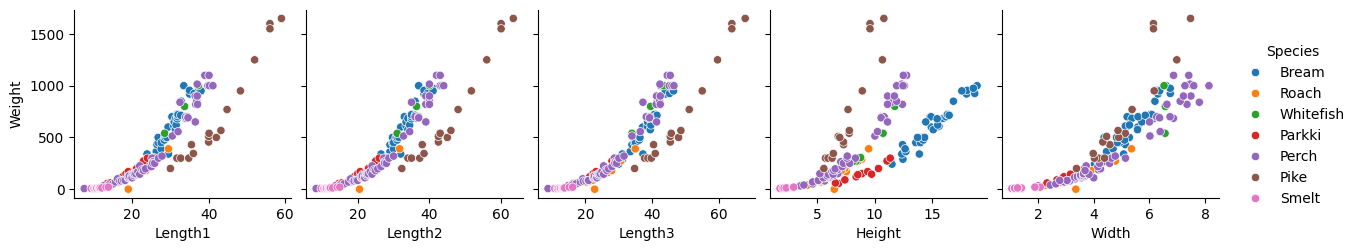

In [3]:
sns.pairplot(df, x_vars=['Length1', 'Length2', 'Length3', 'Height', 'Width'], y_vars='Weight', hue='Species')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge # or Lasso/ElasticNet

# Split data
X = df.drop('Weight', axis=1)
y = df['Weight']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define preprocessing
numeric_features = ['Length1', 'Length2', 'Length3', 'Height', 'Width']
categorical_features = ['Species']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

In [6]:
# Baseline Model
baseline_model = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', LinearRegression())])

# Your Chosen Model (Example: Ridge)
ridge_model = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', Ridge(alpha=1.0))])

# Fit and Compare
baseline_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)

print(f"Baseline Score: {baseline_model.score(X_test, y_test)}")
print(f"Ridge Score: {ridge_model.score(X_test, y_test)}")

Baseline Score: 0.9507352480054508
Ridge Score: 0.946498500142947


Hence, both models explain about 95% of the variance in fish weight, which indicates a very strong fit. As they perform nearly identical, it also suggests the relationship between fish measurements and weight is linear. 
Ridge is a "regularization" model designed to prevent overfitting, the fact that it doesn't significantly outperform the baseline suggests the simple model isn't overcomplicating things or "memorizing" the noise.